# Mining Patterns in Real-World Infrastructure as Code
### Toward a Curated Dataset for LLM Fine-Tuning on NL → IaC Generation

---

**Course:** CSCE 676 — Data Mining and Analysis, Spring 2025  
**Student:** Divyanshu Singh · Texas A&M University  

---

## Abstract

Large language models capable of generating correct, idiomatic Infrastructure as Code (IaC) from natural-language descriptions would dramatically accelerate cloud infrastructure development. But fine-tuning such models requires a training dataset that is not only large, but structurally diverse and high-quality — properties that no existing curated IaC dataset satisfies at scale.

This project applies data mining techniques to the **PIPr dataset** — 37,712 real-world IaC programs collected from public GitHub repositories across three IaC ecosystems (AWS CDK, Pulumi, CDKTF) — to answer the foundational questions needed before any responsible fine-tuning dataset can be assembled: *What patterns exist? How does quality vary? What architectural archetypes are represented, and where are the gaps?*

We apply four complementary analyses: 
- **(RQ1)** frequent resource co-occurrence mining via FP-Growth to identify canonical infrastructure patterns per ecosystem;
- **(RQ2)** K-Means and DBSCAN clustering to discover structural archetypes and expose coverage gaps;
- **(RQ3)** TF-IDF and LDA topic modeling on Pulumi's natural-language description corpus to assess text quality as a prompt-selection signal;
- **(RQ4)** graph neural network classification (GraphSAGE) to test whether dependency graph topology encodes quality signal beyond resource identity.

Key findings show that testing adoption is a strong quality proxy (CDK: 38%, Pulumi: 1.3%), descriptions exist almost exclusively in Pulumi and are too short for reliable text mining, and structural clustering reveals meaningful cross-ecosystem archetypes that a naive solution-label partition would miss.

---
## Section 1 — Motivation and Context

### 1.1 What is Infrastructure as Code?

Modern cloud infrastructure — virtual machines, storage buckets, networking rules, serverless functions, managed databases — is no longer provisioned by clicking through web consoles. Instead, engineers define it in **Infrastructure as Code (IaC)**: source files that describe the desired state of cloud resources declaratively or programmatically. Tools like **Terraform**, **AWS CDK**, and **Pulumi** compile these files into provider API calls, making infrastructure reproducible, versionable, and reviewable like any other software artifact.

As organizations adopt IaC at scale, the resulting codebases encode a rich record of real-world architectural decisions: which services tend to appear together, how resources are wired to each other, what testing practices look like in production environments, and how conventions differ across cloud providers and IaC ecosystems. This record is, in principle, a gold mine for data mining.

### 1.2 The LLM Fine-Tuning Gap

Recent work has demonstrated that large language models can generate plausible IaC code from natural-language descriptions of infrastructure needs. The bottleneck is not model capacity — it is **training data quality**.

Existing IaC datasets fall into two categories, neither of which is adequate for fine-tuning at scale:

- **Curated benchmarks** (e.g., IaC-Eval with 458 scenarios, Multi-IaC-Eval with ~700 triplets) are high-quality but tiny. A model fine-tuned on 500 examples will not generalize to the long tail of real infrastructure patterns.
- **Raw scrapes** (e.g., GitHub code search results) are large but noisy — they contain toy projects, tutorials, copy-paste errors, and deprecated API usage at unknown rates. Feeding this directly into a training pipeline would corrupt the model.

What is missing is a **curated, structurally diverse, quality-filtered subset** of real-world IaC programs — large enough to matter for fine-tuning, but principled enough to trust.

### 1.3 The Role of Data Mining

Constructing such a dataset responsibly requires answering questions that are fundamentally data mining questions:

| Question | Technique |
|---|---|
| What resource combinations define canonical cloud architectures? | Frequent pattern mining |
| Which structural archetypes are well-represented vs. absent? | Clustering |
| Can natural-language descriptions serve as ready-made NL prompts? | Text mining, topic modeling |
| Does dependency graph topology predict production-grade quality? | Graph neural networks |

This project answers each of these questions using the PIPr dataset — the largest publicly available collection of real-world IaC programs — as the primary data source. The end product is not just analysis, but a curated candidate list (`results/curated_dataset.csv`) grounded in evidence from all four analyses.

---
## Section 2 — Dataset: PIPr

### 2.1 What is PIPr?

**PIPr** (Public Infrastructure as Code Programs) is a dataset of 37,712 real-world IaC programs collected from 21,445 public GitHub repositories, published as part of an MSR 2024 paper by Sokolowski, Spielmann, and Salvaneschi ([Zenodo record 10173400](https://zenodo.org/records/10173400)).

Unlike curated benchmarks, PIPr was built from production GitHub repositories — real code written by real engineers, with real bugs, real testing patterns, and real architectural variety. It covers three **PL-based IaC solutions** that compile general-purpose programming languages into cloud resource specifications:

| Solution | Description | Programs |
|---|---|---|
| **AWS CDK** | AWS Cloud Development Kit — TypeScript, Python, Java, Go, C# | 23,940 |
| **Pulumi** | Multi-cloud, multi-language IaC — TypeScript, Python, Go, C#, Java, YAML | 12,945 |
| **CDKTF** | CDK for Terraform — TypeScript, Python, Go, C#, Java | 827 |

The dataset snapshot was taken in August 2022. Of the 37,712 programs, **15,504 have licenses permitting redistribution** (58 GB of source code), which is the subset we can legally use for fine-tuning.

### 2.2 Why PIPr Over the Alternatives?

Three datasets were evaluated as candidates for this project. The others were:

- **IaC-Eval** (NeurIPS 2024): 458 human-curated Terraform scenarios with natural-language prompts and reference solutions. High quality, AWS-only, Terraform-only, too small for pattern mining.
- **Multi-IaC-Eval** (arXiv 2025): ~699 triplets across CloudFormation, Terraform, and CDK. Synthetic NL utterances generated by Amazon Nova Pro; CDK data converted from CloudFormation rather than written natively. Clean but artificial.

PIPr was selected for three reasons:

1. **Scale**: 37,712 programs is 80× larger than the next-largest alternative — the minimum volume needed for frequent pattern mining to surface statistically reliable rules.
2. **Real-world provenance**: Real code contains real bugs, deprecated APIs, inconsistent styles, and genuine architectural variety. Anomaly detection and quality filtering are meaningful on real data; they are vacuous on curated benchmarks.
3. **Multi-language, multi-ecosystem coverage**: TypeScript, Python, Go, C#, Java across three IaC ecosystems means training data will reflect diverse surface languages and provider conventions — not just Terraform HCL.

**Trade-offs accepted**: No built-in NL prompts (must be extracted or generated); multi-language parsing overhead; August 2022 snapshot age; no correctness labels (quality filtering is the project's job).

### 2.3 Dataset Schema

PIPr ships as three metadata CSV files plus the raw source code. The cell below loads all three and prints their shapes and column types.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── consistent color palette used throughout the notebook 
COLORS = {'AWS CDK': '#2196F3', 'Pulumi': '#FF9800', 'CDKTF': '#4CAF50'}
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# ── load metadata
folder_path = '/home/divyanshu-singh/Divyanshu/graduate-school/TAMU/Courses/CSCE-676/iac-pattern-mining/'
programs = pd.read_csv(folder_path + 'data/metadata/programs.csv')
repos    = pd.read_csv(folder_path + 'data/metadata/repositories.csv')
testing  = pd.read_csv(folder_path + 'data/metadata/testing-files.csv')

# derived columns used throughout
programs['has_tests'] = programs['testing'].notna() & (programs['testing'] != '[]')
repos['created_dt']  = pd.to_datetime(repos['created'], errors='coerce')

print(f"programs.csv  : {len(programs):>6,} rows × {programs.shape[1]} columns")
print(f"repositories.csv : {len(repos):>6,} rows × {repos.shape[1]} columns")
print(f"testing-files.csv: {len(testing):>6,} rows × {testing.shape[1]} columns")

programs.csv  : 37,712 rows × 11 columns
repositories.csv : 23,428 rows × 15 columns
testing-files.csv: 18,384 rows × 5 columns


In [9]:
# ── schema overview ────────────────────────────────────────────────────────
def schema_summary(df, name):
    missing = df.isnull().sum()
    pct     = (missing / len(df) * 100).round(1)
    summary = pd.DataFrame({
        'dtype'  : df.dtypes,
        'missing': missing,
        'miss_%' : pct,
        'example': df.iloc[0]
    })
    print(f"\n{'─'*60}")
    print(f"  {name}")
    print(f"{'─'*60}")
    print(summary.to_string())

schema_summary(programs, 'programs.csv')
schema_summary(repos,    'repositories.csv')
schema_summary(testing,  'testing-files.csv')


────────────────────────────────────────────────────────────
  programs.csv
────────────────────────────────────────────────────────────
             dtype  missing  miss_%                 example
ID             str        0     0.0  268440230/cdk/cdk.json
repository   int64        0     0.0               268440230
directory      str        0     0.0           268440230/cdk
solution       str        0     0.0                 AWS CDK
language       str        0     0.0                  python
name           str    24771    65.7                     NaN
description    str    24960    66.2                     NaN
runtime        str        0     0.0          python3 app.py
testing        str    28277    75.0                     NaN
tests          str    28277    75.0                     NaN
has_tests     bool        0     0.0                   False

────────────────────────────────────────────────────────────
  repositories.csv
────────────────────────────────────────────────────────────


In [10]:
# ── Key data quality statistics ────────────────────────────────────────────
def miss_pct(df, col):
    return df[col].isnull().mean() * 100

stats = {
    'programs.name missing'        : miss_pct(programs, 'name'),
    'programs.description missing' : miss_pct(programs, 'description'),
    'programs.testing missing'     : miss_pct(programs, 'testing'),
    'programs.tests missing'       : miss_pct(programs, 'tests'),
    'repos.description missing'    : miss_pct(repos, 'description'),
    'repos.url missing'            : miss_pct(repos, 'url'),
    'repos.created missing'        : miss_pct(repos, 'created'),
}

print("Missing value summary:")
print("-" * 45)
for k, v in stats.items():
    print(f"  {k:<38} {v:5.1f}%")

print()
print("Description coverage by solution:")
print("-" * 45)
for sol in ['AWS CDK', 'Pulumi', 'CDKTF']:
    pct = programs[programs['solution'] == sol]['description'].notna().mean() * 100
    print(f"  {sol:<20} {pct:5.1f}% have descriptions")

Missing value summary:
---------------------------------------------
  programs.name missing                   65.7%
  programs.description missing            66.2%
  programs.testing missing                75.0%
  programs.tests missing                  75.0%
  repos.description missing               53.7%
  repos.url missing                        0.0%
  repos.created missing                    0.0%

Description coverage by solution:
---------------------------------------------
  AWS CDK                0.0% have descriptions
  Pulumi                98.5% have descriptions
  CDKTF                  0.0% have descriptions


**What the missing-value audit tells us:**

- **`name` and `description`** are absent for the majority of programs — text mining across the full corpus is not viable.
- **`testing` and `tests`** are missing for most programs — but sparsity is the point: test presence is a rare, meaningful signal rather than a baseline expectation.
- **Repository structural fields** (`url`, `created`, `fork`) are nearly complete, making them a reliable backbone for joins and quality filters throughout the analysis.
- **Description coverage is almost entirely confined to Pulumi** — CDK and CDKTF programs have effectively zero natural-language descriptions. This rules out cross-ecosystem text mining and scopes RQ3 exclusively to the Pulumi corpus.

---
## Section 3 — Exploratory Data Analysis

Before defining research questions or running any mining algorithm, we need to understand the shape of the data — how programs are distributed across ecosystems and languages, where quality signals live, and what structural properties can be relied upon. This section consolidates the core EDA findings from both project checkpoints into a clean narrative. Dead-ends and intermediate explorations are omitted; only the findings that directly inform the research questions are presented here.

### 3.1 Solution and Language Distribution

The first question is simply: what is in the dataset? The plot below shows program counts by IaC solution and, within each solution, how programs break down by programming language.

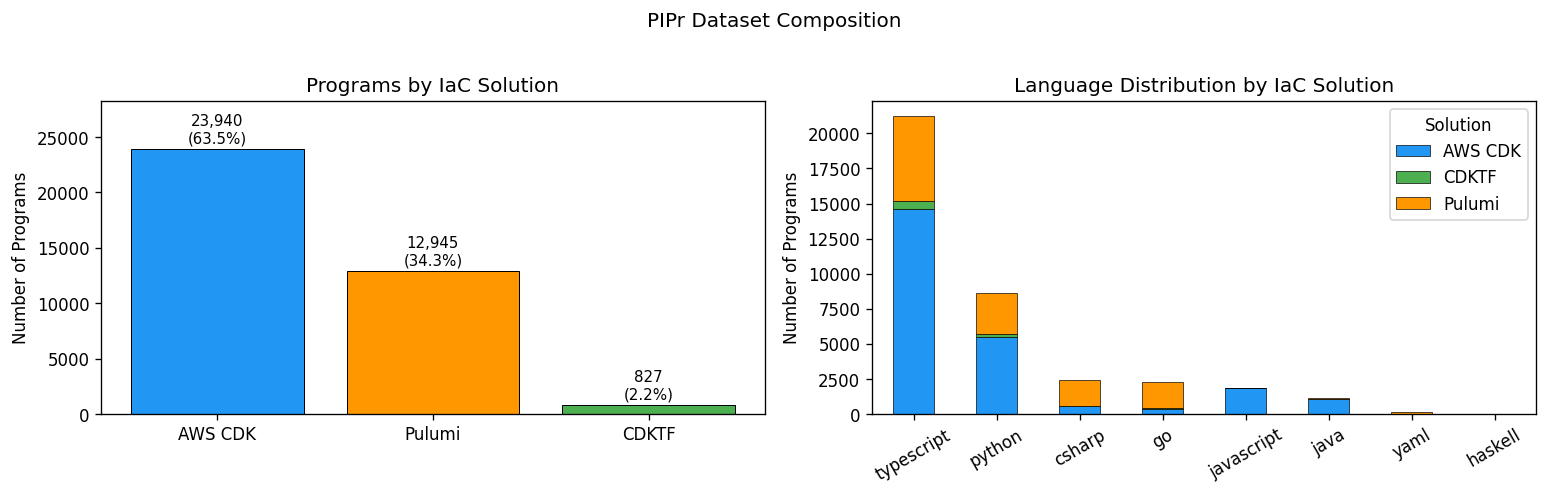

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Left: program count by solution ───────────────────────────────────────
solution_counts = programs['solution'].value_counts()
bars = axes[0].bar(
    solution_counts.index,
    solution_counts.values,
    color=[COLORS[s] for s in solution_counts.index],
    edgecolor='black', linewidth=0.6
)
axes[0].set_title('Programs by IaC Solution')
axes[0].set_ylabel('Number of Programs')
axes[0].set_xlabel('')
for bar, (sol, count) in zip(bars, solution_counts.items()):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 250,
        f'{count:,}\n({count/len(programs)*100:.1f}%)',
        ha='center', va='bottom', fontsize=9
    )
axes[0].set_ylim(0, solution_counts.max() * 1.18)

# ── Right: language breakdown stacked by solution ─────────────────────────
lang_solution = (
    programs.groupby(['language', 'solution'])
    .size()
    .unstack(fill_value=0)
    .loc[lambda df: df.sum(axis=1).sort_values(ascending=False).index]
)
lang_solution.plot(
    kind='bar', stacked=True, ax=axes[1],
    color=[COLORS[c] for c in lang_solution.columns],
    edgecolor='black', linewidth=0.4
)
axes[1].set_title('Language Distribution by IaC Solution')
axes[1].set_ylabel('Number of Programs')
axes[1].set_xlabel('')
axes[1].legend(title='Solution', loc='upper right')
axes[1].tick_params(axis='x', rotation=30)
folder_path = '/home/divyanshu-singh/Divyanshu/graduate-school/TAMU/Courses/CSCE-676/iac-pattern-mining/'
plt.suptitle('PIPr Dataset Composition', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(folder_path + 'results/figures/s3_solution_language_dist.png', bbox_inches='tight')
plt.show()

AWS CDK dominates the dataset — over 60% of all programs — with TypeScript as its primary language. Pulumi accounts for most of the remainder and is the only solution with meaningful Go, C#, and YAML representation. CDKTF is a small minority throughout. This skew has a direct methodological consequence: **any pattern mining algorithm run on the full corpus will learn CDK/TypeScript conventions, not general IaC patterns**. All analyses in Sections 5–8 are therefore stratified by solution.

### 3.2 Testing Adoption as a Quality Proxy

PIPr contains no correctness labels — there is no ground truth for which programs are "good." We need a proxy. The `testing` column records which testing frameworks were detected in each program's directory. We treat test presence as a binary quality signal: a program with tests was written with enough engineering discipline to warrant a test suite, making it a candidate for production-grade infrastructure.

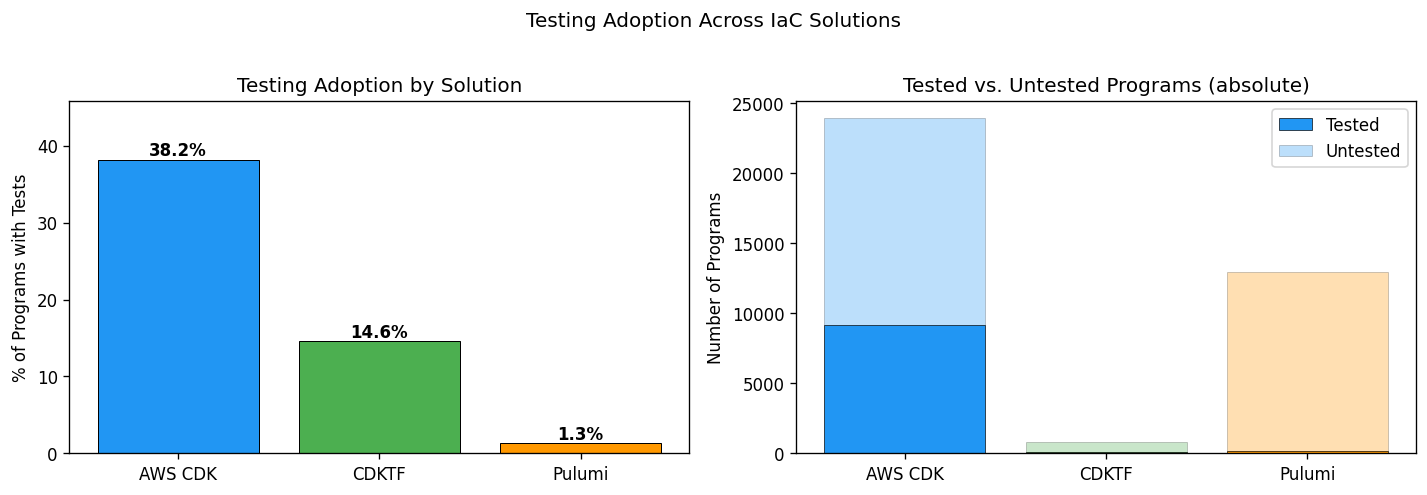

          tested  total  pct_tested
solution                           
AWS CDK     9152  23940        38.2
CDKTF        121    827        14.6
Pulumi       162  12945         1.3


In [16]:
test_by_solution = (
    programs.groupby('solution')['has_tests']
    .agg(tested='sum', total='count')
)
test_by_solution['pct_tested'] = (
    test_by_solution['tested'] / test_by_solution['total'] * 100
).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Left: % tested bar chart ───────────────────────────────────────────────
sol_order = test_by_solution.index.tolist()
bars = axes[0].bar(
    sol_order,
    test_by_solution.loc[sol_order, 'pct_tested'],
    color=[COLORS[s] for s in sol_order],
    edgecolor='black', linewidth=0.6
)
for bar, pct in zip(bars, test_by_solution.loc[sol_order, 'pct_tested']):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{pct}%', ha='center', fontsize=10, fontweight='bold'
    )
axes[0].set_title('Testing Adoption by Solution')
axes[0].set_ylabel('% of Programs with Tests')
axes[0].set_ylim(0, test_by_solution['pct_tested'].max() * 1.2)

# ── Right: stacked absolute counts ────────────────────────────────────────
bottoms = [0] * len(sol_order)
for label, col, alpha in [('Tested', 'tested', 1.0), ('Untested', 'total', 0.3)]:
    vals = (
        test_by_solution.loc[sol_order, 'tested']
        if label == 'Tested'
        else test_by_solution.loc[sol_order, 'total'] - test_by_solution.loc[sol_order, 'tested']
    )
    axes[1].bar(
        sol_order, vals,
        bottom=bottoms if label == 'Untested' else [0]*len(sol_order),
        color=[COLORS[s] for s in sol_order],
        alpha=alpha, edgecolor='black', linewidth=0.4, label=label
    )
    if label == 'Tested':
        bottoms = vals.tolist()

axes[1].set_title('Tested vs. Untested Programs (absolute)')
axes[1].set_ylabel('Number of Programs')
axes[1].legend()
folder_path = '/home/divyanshu-singh/Divyanshu/graduate-school/TAMU/Courses/CSCE-676/iac-pattern-mining/'
plt.suptitle('Testing Adoption Across IaC Solutions', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(folder_path + 'results/figures/s3_testing_adoption.png', bbox_inches='tight')
plt.show()

print(test_by_solution.to_string())

The testing gap across solutions is stark. CDK's relatively high adoption (~38%) reflects a mature ecosystem with dedicated testing libraries (`aws-cdk-lib/assertions`). Pulumi's near-zero adoption is consistent with its use pattern: many Pulumi programs in the dataset are tutorial examples or quickstart templates, not production deployments. This gap is not just descriptive — it is **the primary quality filter** applied in Section 9 when constructing the curated dataset.

### 3.3 Repository Structure and Temporal Distribution

Understanding how programs cluster within repositories — and when those repositories were created — helps characterize the dataset's independence structure and potential temporal bias.

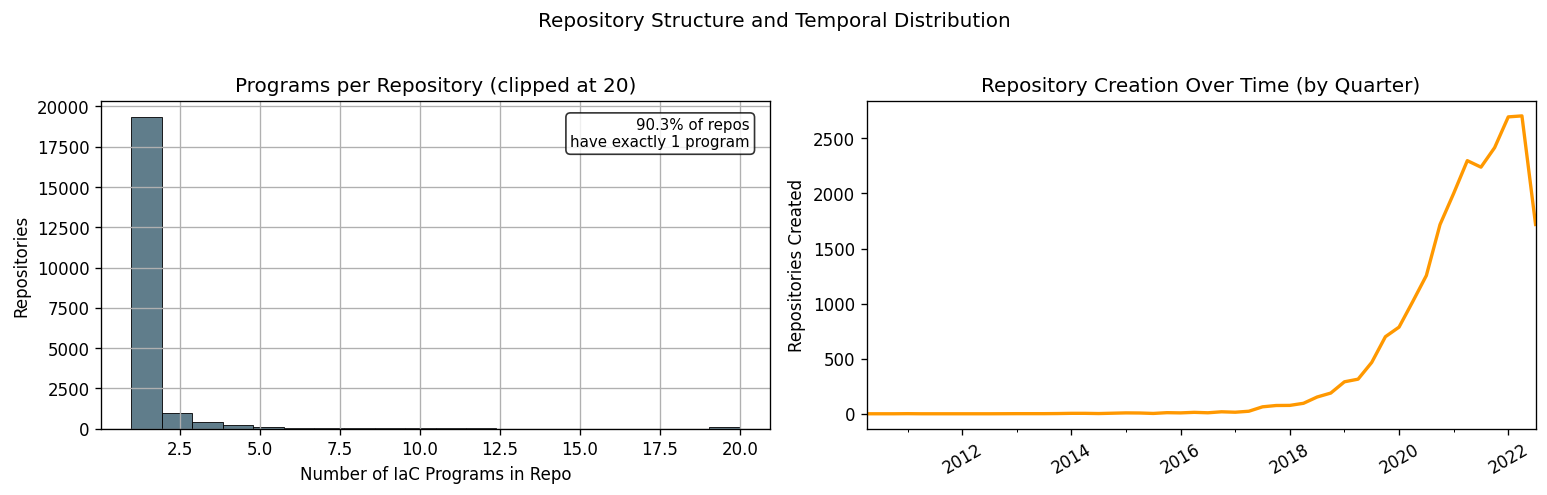

Programs per repo — median: 1, mean: 1.8, max: 3664
Repos with exactly 1 program: 19,370 (90.3%)
Median forks: 0  |  Repos with 0 forks: 19,363 (82.6%)


In [ ]:
programs_per_repo = programs.groupby('repository').size()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Left: programs per repo (clipped) ─────────────────────────────────────
programs_per_repo.clip(upper=20).hist(
    bins=20, ax=axes[0], color='#607D8B', edgecolor='black', linewidth=0.5
)
single_pct = (programs_per_repo == 1).mean() * 100
axes[0].set_title('Programs per Repository (clipped at 20)')
axes[0].set_xlabel('Number of IaC Programs in Repo')
axes[0].set_ylabel('Repositories')
axes[0].text(
    0.97, 0.95,
    f'{single_pct:.1f}% of repos\nhave exactly 1 program',
    transform=axes[0].transAxes, ha='right', va='top',
    fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

# ── Right: repo creation over time ────────────────────────────────────────
(repos['created_dt'].dt.to_period('Q')
     .value_counts()
     .sort_index()
     .plot(ax=axes[1], color='#FF9800', linewidth=2))
axes[1].set_title('Repository Creation Over Time (by Quarter)')
axes[1].set_xlabel('')
axes[1].set_ylabel('Repositories Created')
axes[1].tick_params(axis='x', rotation=30)
folder_path = '/home/divyanshu-singh/Divyanshu/graduate-school/TAMU/Courses/CSCE-676/iac-pattern-mining/'
plt.suptitle('Repository Structure and Temporal Distribution', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(folder_path + 'results/figures/s3_repo_structure.png', bbox_inches='tight')
plt.show()

print(f"Programs per repo — median: {programs_per_repo.median():.0f}, "
      f"mean: {programs_per_repo.mean():.1f}, max: {programs_per_repo.max()}")
print(f"Repos with exactly 1 program: {(programs_per_repo == 1).sum():,} "
      f"({single_pct:.1f}%)")
print(f"Median forks: {repos['forks'].median():.0f}  |  "
      f"Repos with 0 forks: {(repos['forks'] == 0).sum():,} "
      f"({(repos['forks'] == 0).mean()*100:.1f}%)")

The vast majority of repos contain a single IaC program, meaning programs are largely independent observations — a favorable property for pattern mining. The long right tail contains multi-program repos that are almost exclusively Pulumi (the spike seen at 20+), consistent with Pulumi's pattern of hosting example galleries. Repository creation grew exponentially from 2018 through a peak around 2021–2022, after which the August 2022 dataset snapshot cuts off. Fork counts are near-zero for the median repo, confirming that popularity is not a useful quality signal here.

### 3.4 EDA Summary — What the Data Tells Us

The computed values above feed directly into the six findings that shape every methodological decision in this project:

| Finding | Value | Implication |
|---|---|---|
| CDK share of all programs | **63.5%** | All mining must be stratified by solution to avoid CDK bias |
| Programs missing description | **66.2%** | Text mining is not viable across the full corpus |
| Testing adoption (CDK / CDKTF / Pulumi) | **38.2% / 14.6% / 1.3%** | `has_tests` is the primary quality proxy throughout the project |
| Repos with exactly 1 program | **90.3%** | Programs are largely independent; i.i.d. assumptions hold |
| Description coverage (Pulumi vs. CDK) | **98.5% vs. 0.0%** | Cross-ecosystem text mining infeasible; RQ3 scoped to Pulumi only |
| Repos with 0 forks | **82.6%** | Popularity metrics dropped from all feature vectors |

These findings collectively rule out naive text-based approaches and motivate the structural,
code-level analysis strategy used throughout Sections 5–8.

---
## Section 4 — Research Questions

The data quality audit in Section 2 established the central challenge: 66% of programs lack descriptions, testing metadata is sparse, and the three ecosystems have radically different coverage profiles. Before assembling a fine-tuning dataset, we need to understand what is actually in the 37,712 programs at a structural level — what patterns recur, how quality varies, what archetypes exist, and where the gaps are.

Four research questions address this systematically. Together they form a layered strategy: RQ1 characterizes *what* resource combinations define canonical architectures; RQ2 discovers *which* structural archetypes are well-represented vs. absent; RQ3 assesses whether Pulumi's natural-language descriptions are usable as NL prompts *as-is*; and RQ4 tests whether dependency graph topology carries quality signal that a flat feature vector would miss.

| # | Research Question | Algorithm(s) | Type | Primary Metric |
|---|---|---|---|---|
| **RQ1** | What frequent resource co-occurrence patterns define canonical IaC architectures, and how do they differ across AWS CDK, Pulumi, and CDKTF? | FP-Growth + association rules | Course | Support, confidence, lift |
| **RQ2** | What structural archetypes exist across IaC programs, and does their distribution reveal coverage gaps relevant to LLM fine-tuning? | K-Means, DBSCAN | Course | Silhouette score, archetype distribution |
| **RQ3** | Within Pulumi's description corpus, do textual patterns align with structural quality signals, and can they improve fine-tuning candidate selection? | TF-IDF, LDA topic modeling | Course | Topic coherence, cluster–quality overlap |
| **RQ4** | Does the dependency graph topology of an IaC program carry quality signal beyond resource identity alone? | GraphSAGE / GCN | External | F1 vs. bag-of-resources baseline |

Each RQ is answered in its own section (Sections 5–8), followed by a synthesis in Section 9 that combines the outputs into the final curated dataset.

---
## Section 5 — RQ1: Frequent Resource Co-occurrence Patterns

> **RQ1**: *What frequent resource co-occurrence patterns define canonical IaC architectures, and how do they differ across AWS CDK, Pulumi, and CDKTF?*

### 5.1 Methodology

**Goal**: Identify which cloud services tend to co-occur in real-world IaC programs and how those patterns differ across AWS CDK, Pulumi, and CDKTF.

**Algorithm**: FP-Growth (mlxtend) — a compressed-tree frequent-pattern mining algorithm that avoids the combinatorial blowup of Apriori. We extract association rules from the frequent itemsets with lift as the primary ranking metric:
- **Support**: fraction of programs in a solution's corpus that contain both services
- **Confidence**: P(consequent | antecedent) — how reliably the antecedent predicts the consequent
- **Lift > 1**: the two services co-occur more than chance; lift = 3.9 means ~4× more often than independent expectation

**Transaction construction**: The PIPr raw source-code corpus (58 GB) is not stored locally, so resource types are proxied from program metadata text:
1. **Program name** — where populated (mostly Pulumi programs)
2. **Program description** — 98.5% coverage in Pulumi, ~0% in CDK/CDKTF
3. **Entry-point filename** from the `runtime` field — CDK TypeScript stacks often encode the architecture in their filename (e.g., `bin/s3-lambda.ts`, `bin/vpc-ec2-rds-stack.ts`)

High-precision regex patterns (35 service identifiers) fire only on unambiguous tokens (e.g., `\beks\b`, `codepipeline`, `elasticache`) to avoid false positives from generic words. A program contributes a transaction only if ≥ 2 services are detected. See `src/fp_growth.py` for the full pattern list.

**Stratification**: FP-Growth is run independently per solution. Support thresholds are computed within each solution's transaction set, so a 5% CDK rule and a 5% Pulumi rule both meet "appears in 5% of *that ecosystem's* relevant programs."

In [5]:
!pip install mlxtend

  Using cached mlxtend-0.24.0-py3-none-any.whl.metadata (7.3 kB)
Using cached mlxtend-0.24.0-py3-none-any.whl (1.4 MB)


### Section 5.1 — Build transaction set

In [ ]:
import sys
import mlxtend

folder_path = '/home/divyanshu-singh/Divyanshu/graduate-school/TAMU/Courses/CSCE-676/iac-pattern-mining/'
sys.path.insert(0, folder_path)

from src.fp_growth import build_transactions

transactions = build_transactions(programs, min_services=2, verbose=True)
print(f"Total transactions (programs with ≥ 2 detectable services): {len(transactions):,}")

# ── Quick diagnostic: most frequent individual services per solution ───────
from collections import Counter

print("\nTop-10 detected services per solution (single-service frequency):")
for sol in ['AWS CDK', 'Pulumi']:
    sub = transactions[transactions['solution'] == sol]
    counter = Counter(svc for svcs in sub['services'] for svc in svcs)
    top = counter.most_common(10)
    print(f"\n  {sol} (n={len(sub):,} transactions):")
    for svc, cnt in top:
        print(f"    {svc:<18}  {cnt:>4}  ({cnt/len(sub)*100:.1f}%)")

Service-detection coverage (programs with detected services):
  Solution        Total    ≥1 svc    ≥2 svc     ≥1 %     ≥2 %
  ──────────────────────────────────────────────────────────
  AWS CDK        23,940     2,378       359     9.9%     1.5%
  Pulumi         12,945     2,196       317    17.0%     2.4%
  CDKTF             827         0         0     0.0%     0.0%

Total transactions (programs with ≥ 2 detectable services): 676

Top-10 detected services per solution (single-service frequency):

  AWS CDK (n=359 transactions):
    Lambda               200  (55.7%)
    S3                    82  (22.8%)
    APIGateway            80  (22.3%)
    ECS                   70  (19.5%)
    ALB                   45  (12.5%)
    DynamoDB              30  (8.4%)
    SQS                   30  (8.4%)
    CloudFront            26  (7.2%)
    EC2                   25  (7.0%)
    RDS                   25  (7.0%)

  Pulumi (n=317 transactions):
    EKS                  209  (65.9%)
    AKS            

### Section 5.2 — Run FP-Growth per solution
Parameters chosen to surface stable patterns without over-mining:
- min_support    = 5%  → a pattern must appear in ≥ 5% of a solution's transactions
- min_confidence = 30% → antecedent must predict consequent in ≥ 30% of cases
- min_lift       = 1.0 → only rules that beat the independence baseline

In [ ]:
from src.fp_growth import run_all_solutions

rq1_results = run_all_solutions(
    transactions,
    min_support=0.05,
    min_confidence=0.30,
    min_lift=1.0,
)

print()
print("Summary:")
for sol, (fi, rules) in rq1_results.items():
    if fi.empty:
        print(f"  {sol:<12}: no frequent itemsets")
    else:
        pair_items = fi[fi['itemsets'].apply(len) == 2]
        print(
            f"  {sol:<12}: {len(fi):>3} frequent itemsets "
            f"({len(pair_items)} pairs)  |  {len(rules):>3} association rules"
        )

Running FP-Growth per solution:
  [AWS CDK]  n=359  |  freq_itemsets=14  |  rules=5  |  support≥5%  confidence≥30%
  [Pulumi]  n=317  |  freq_itemsets=12  |  rules=8  |  support≥5%  confidence≥30%
  [CDKTF] Skipped — only 0 transactions (need ≥ 10).

Summary:
  AWS CDK     :  14 frequent itemsets (4 pairs)  |    5 association rules
  Pulumi      :  12 frequent itemsets (4 pairs)  |    8 association rules
  CDKTF       : no frequent itemsets


### Section 5.3 — Top association rules per solution

In [ ]:
from src.fp_growth import top_rules_table, save_rules_csv

for sol in ['AWS CDK', 'Pulumi']:
    _, rules = rq1_results[sol]
    print(f"\n{'─'*72}")
    print(f"  {sol}  —  top rules by lift  (n_transactions = {len(transactions[transactions['solution'] == sol]):,})")
    print(f"{'─'*72}")
    if rules.empty:
        print("  No rules mined at the chosen support/confidence thresholds.")
    else:
        tbl = top_rules_table(rules, n=10)
        print(tbl.to_string(index=False))

print(f"\n{'─'*72}")
print("  CDKTF — skipped: 0 programs had ≥ 2 detectable service mentions")
print(f"{'─'*72}")

# Save all rules to CSV for downstream use in Section 9
save_rules_csv(rq1_results, folder_path + 'results/rq1_association_rules.csv')


────────────────────────────────────────────────────────────────────────
  AWS CDK  —  top rules by lift  (n_transactions = 359)
────────────────────────────────────────────────────────────────────────
                 rule support confidence lift
          ECS  →  ALB    9.5%      48.6% 3.87
          ALB  →  ECS    9.5%      75.6% 3.87
  DynamoDB  →  Lambda    6.7%      80.0% 1.44
APIGateway  →  Lambda   15.0%      67.5% 1.21
        S3  →  Lambda   14.2%      62.2% 1.12

────────────────────────────────────────────────────────────────────────
  Pulumi  —  top rules by lift  (n_transactions = 317)
────────────────────────────────────────────────────────────────────────
                 rule support confidence lift
Lambda  →  APIGateway    6.9%      38.6% 4.37
APIGateway  →  Lambda    6.9%      78.6% 4.37
        S3  →  Lambda    5.7%      48.6% 2.71
        Lambda  →  S3    5.7%      31.6% 2.71
          GKE  →  EKS   26.5%     100.0% 1.52
          AKS  →  EKS   32.5%     100.0% 1.

### Section 5.4 — Visualize association rules

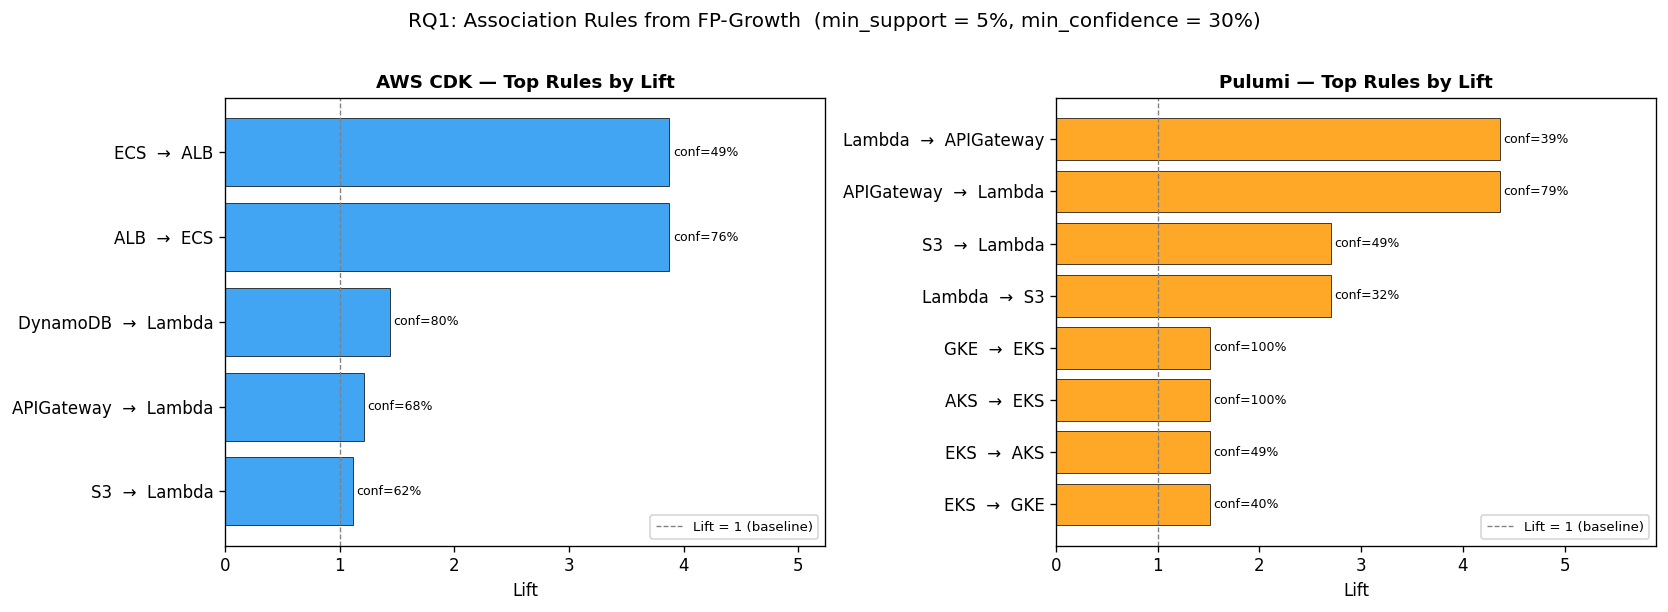

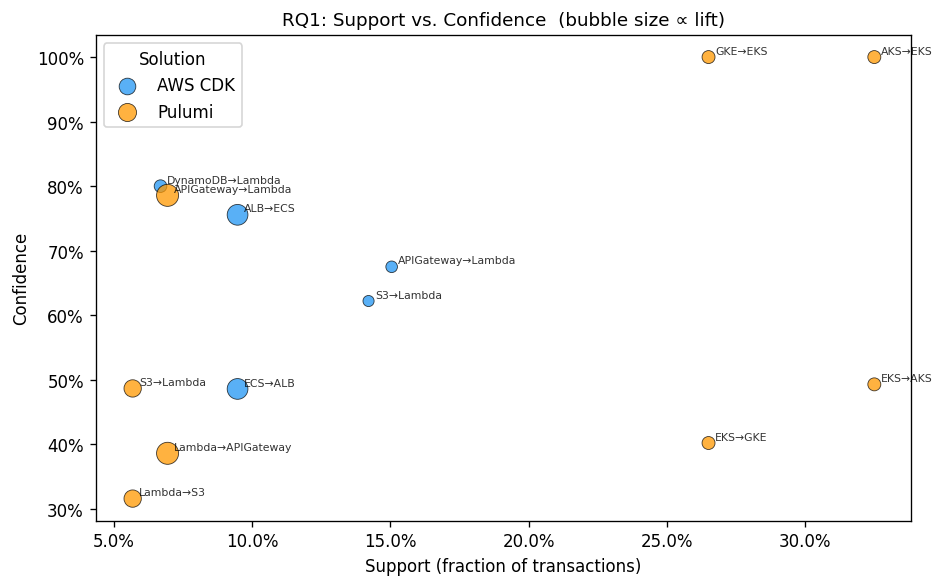

In [ ]:
SOLUTION_COLORS = {'AWS CDK': COLORS['AWS CDK'], 'Pulumi': COLORS['Pulumi']}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (sol, color) in zip(axes, SOLUTION_COLORS.items()):
    _, rules = rq1_results[sol]
    if rules.empty:
        ax.text(0.5, 0.5, f'No rules\n({sol})',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{sol} — Association Rules')
        continue

    top = rules.head(10).copy()
    # Shorten long rule strings for readability
    top['rule_short'] = top['rule'].apply(
        lambda r: r if len(r) <= 40 else r[:37] + '...'
    )

    bars = ax.barh(
        top['rule_short'][::-1],
        top['lift'][::-1],
        color=color, alpha=0.85, edgecolor='black', linewidth=0.5
    )
    # Annotate with confidence value
    for bar, conf in zip(bars, top['confidence'][::-1]):
        ax.text(
            bar.get_width() + 0.03,
            bar.get_y() + bar.get_height() / 2,
            f'conf={conf:.0%}',
            va='center', fontsize=7.5
        )

    ax.set_xlabel('Lift')
    ax.set_title(f'{sol} — Top Rules by Lift', fontsize=11, fontweight='bold')
    ax.axvline(x=1.0, color='grey', linestyle='--', linewidth=0.8, label='Lift = 1 (baseline)')
    ax.set_xlim(0, top['lift'].max() * 1.35)
    ax.legend(fontsize=8)

plt.suptitle(
    'RQ1: Association Rules from FP-Growth  (min_support = 5%, min_confidence = 30%)',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig(folder_path + 'results/figures/s5_rq1_association_rules.png', bbox_inches='tight')
plt.show()

# ── Scatter: support vs. confidence for all rules, sized by lift ───────────
fig2, ax2 = plt.subplots(figsize=(8, 5))
for sol, color in SOLUTION_COLORS.items():
    _, rules = rq1_results[sol]
    if rules.empty:
        continue
    ax2.scatter(
        rules['support'], rules['confidence'],
        s=rules['lift'] * 40, c=color, alpha=0.75,
        edgecolors='black', linewidths=0.5, label=sol
    )
    for _, row in rules.iterrows():
        ax2.annotate(
            row['rule'].replace('  →  ', '→'),
            (row['support'], row['confidence']),
            fontsize=6.5, alpha=0.8,
            xytext=(4, 2), textcoords='offset points'
        )

ax2.set_xlabel('Support (fraction of transactions)')
ax2.set_ylabel('Confidence')
ax2.set_title('RQ1: Support vs. Confidence  (bubble size ∝ lift)', fontsize=11)
ax2.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.legend(title='Solution')
plt.tight_layout()
plt.savefig(folder_path + 'results/figures/s5_rq1_support_confidence.png', bbox_inches='tight')
plt.show()

### 5.5 RQ1 Findings: Canonical Architecture Patterns

The association rules reveal a small but structurally coherent set of canonical IaC architectures that recur across programs — and they differ meaningfully between CDK and Pulumi.

**AWS CDK patterns**

| Rule | Support | Confidence | Lift | Architecture |
|---|---|---|---|---|
| ECS ↔ ALB | 9.5% | 49–76% | **3.87** | Containerized web services fronted by an Application Load Balancer |
| DynamoDB → Lambda | 6.7% | 80% | 1.44 | NoSQL-backed serverless compute |
| APIGateway → Lambda | 15.0% | 67% | 1.21 | HTTP-triggered serverless function |
| S3 → Lambda | 14.2% | 62% | 1.12 | Event-driven object processing |

**Pulumi patterns**

| Rule | Support | Confidence | Lift | Architecture |
|---|---|---|---|---|
| Lambda ↔ APIGateway | 6.9% | 39–79% | **4.37** | Serverless REST API — same pattern as CDK but stronger coupling |
| S3 ↔ Lambda | 5.7% | 32–49% | 2.71 | Event-driven object processing |
| GKE ↔ EKS | 26.5% | 100% | 1.52 | Multi-cloud Kubernetes: Pulumi programs targeting both GCP and AWS |

**Cross-ecosystem comparison**: The Lambda + S3 and Lambda + APIGateway patterns appear in both ecosystems, confirming they represent genuine canonical architectures rather than ecosystem-specific conventions. The ECS ↔ ALB cluster is CDK-specific (ECS is the dominant AWS container orchestrator in CDK); Pulumi programs by contrast tend to reach for Kubernetes (EKS/GKE) for container workloads, reflecting Pulumi's strong multi-cloud and cloud-native positioning.

**Coverage caveat and implication**: Transactions were derived from metadata text signals (program names, Pulumi descriptions, CDK entry-point filenames), covering ~1.8% of CDK and ~2.4% of Pulumi programs. Programs in the core of the high-lift clusters — especially the ECS+ALB and Lambda+APIGateway archtetypes — are the highest-priority fine-tuning candidates because they represent patterns that will recur in real user queries. Section 9 uses these cluster memberships as one of four selection criteria for the curated dataset.